# STEP 10. 심화 — 개업·폐업 분리 · 칸 고정효과 · 유동인구 구성

STEP 9 까지의 결론은 두 가지였습니다.

- 점포 규모가 압도적 1위 변수인데, 그 상당 부분이 라벨 산술이다
- 유동인구는 점포수를 통제하면 사라진다 (매개)

둘 다 **"순증감의 부호"라는 하나의 결과변수**로만 본 결론입니다. 여기서 셋을 추가합니다.

| 절 | 무엇을 | 왜 |
|---|---|---|
| 10-2 | **개업과 폐업을 분리** | "개업이 없어서 순감소"와 "폐업이 많아서 순감소"는 완전히 다른 현상 |
| 10-3 | **상권 × 업종 고정효과** | 임대료·입지·상권 성격 등 시간불변 교란을 통째로 제거 |
| 10-4 | **유동인구 구성 × 업종 상호작용** | 총량이 아니라 구성. 같은 값이라도 업종마다 다른 기울기 |

## 왜 이 셋인가

`y = [개업(t+1) − 폐업(t+1) < 0]` 은 **두 흐름의 차이**입니다. 어떤 변수가 개업과 폐업을 **같은 방향으로** 움직이면 차이에서 상쇄되어 "무관"하게 보입니다. 10-2 가 그걸 열어봅니다.

그리고 유동인구 세부 컬럼 21개(성별 2 · 연령 6 · 시간대 6 · 요일 7)가 `01_flow.pkl` 에 남아 있습니다. **수준으로 넣으면 총량과 상관 0.95~0.997 이라 무의미하고, 비중으로 바꿔야 새 차원이 생깁니다.**

필요 패키지: 기존 + `statsmodels` (조건부 포아송·음이항)


In [2]:
import sys, os
from pathlib import Path

# 노트북이 어디서 열리든 프로젝트 루트를 찾아 sys.path에 추가
ROOT = Path.cwd()
while not (ROOT / "config.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

# config.py 를 고친 뒤 커널을 재시작하지 않으면 파이썬이 옛 모듈을 캐시한다.
import importlib
if "config" in sys.modules:
    importlib.reload(sys.modules["config"])

import numpy as np
import pandas as pd
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)
print("프로젝트 루트:", ROOT)

프로젝트 루트: c:\Users\spide\ai-data-bootcamp\project\h2_nb


In [3]:
import warnings
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.discrete.conditional_models import ConditionalPoisson, ConditionalLogit
from config import (PROC, FIG, TARGET_TYPE, TREAT_SVC, TRAIN_QUARTERS,
                    build_features, set_korean_font)
set_korean_font()
warnings.filterwarnings("ignore")
OUT = FIG.parent
REF_SVC = TREAT_SVC        # 업종 기준 범주 = 한식음식점

# ── 원본 적재 (_raw 보존) ───────────────────────
panel_raw = pd.read_pickle(PROC / "03_panel.pkl")
flow_raw  = pd.read_pickle(PROC / "01_flow.pkl")
merged_raw = pd.read_pickle(PROC / "02_merged.pkl")

print(f"panel  {panel_raw.shape}")
print(f"flow   {flow_raw.shape}  ← 미사용 세부 컬럼이 여기 있음")
print(f"merged {merged_raw.shape}  ← 필터 이전 원본 (다음 분기 개업·폐업 조회용)")

panel  (67475, 36)
flow   (21434, 24)  ← 미사용 세부 컬럼이 여기 있음
merged (160352, 25)  ← 필터 이전 원본 (다음 분기 개업·폐업 조회용)


## 10-1. 필터 후 작업본 만들기

STEP 1 과 같은 원칙입니다 — `_raw` 는 건드리지 않고, **필요한 범위로 먼저 자른 뒤 `.copy()`** 로 작업합니다.

- 범위: **골목상권 · 학습 분기(20231~20253)**
- 검증 분기(20254)와 예측 분기(20261)는 제외 — 여기서 얻은 판단이 STEP 8 예측으로 넘어가므로 누수 방지

In [4]:
# ① 분석 범위로 먼저 자른다
gm = panel_raw[(panel_raw["상권유형"] == TARGET_TYPE) &
               (panel_raw["기준_년분기_코드"].isin(TRAIN_QUARTERS))].copy()
gm = build_features(gm)
areas = gm["상권_코드"].unique()
print(f"작업본 {len(gm):,}행 | 상권 {len(areas)}개 | 분기 {gm['기준_년분기_코드'].nunique()}개")
assert 20254 not in gm["기준_년분기_코드"].values, "검증 분기가 섞였습니다"

# ② 다음 분기 개업·폐업 카운트 — 필터 이전 원본에서 가져온다 (선택편의 방지)
nx = merged_raw.copy()
nx["분기idx"] = nx["기준_년분기_코드"].map(lambda x: (x // 10) * 4 + (x % 10 - 1))
nx = nx[["상권_코드", "서비스_업종_코드", "분기idx", "개업_점포_수", "폐업_점포_수"]] \
       .rename(columns={"개업_점포_수": "개업_n", "폐업_점포_수": "폐업_n"})

gm = gm.assign(nxt=gm["분기idx"] + 1).merge(
    nx, left_on=["상권_코드", "서비스_업종_코드", "nxt"],
    right_on=["상권_코드", "서비스_업종_코드", "분기idx"],
    how="left", suffixes=("", "_r"), validate="many_to_one")
assert gm["개업_n"].isna().sum() == 0, "다음 분기 카운트를 못 찾은 행이 있습니다"
print(f"다음 분기 카운트 결합 완료 — 결측 0")

작업본 31,875행 | 상권 925개 | 분기 11개
다음 분기 카운트 결합 완료 — 결측 0


### 유동인구 구성비 파생

**수준(level)이 아니라 비중(share)** 으로 만드는 게 핵심입니다. 왜 그런지 먼저 확인합니다.

In [5]:
fl = flow_raw[flow_raw["상권_코드"].isin(areas) &
              flow_raw["기준_년분기_코드"].isin(TRAIN_QUARTERS)].copy()
tot = fl["총_유동인구_수"].replace(0, np.nan)

print("[수준으로 쓰면 총량과 얼마나 겹치나]")
for c in ["시간대_11_14_유동인구_수", "시간대_17_21_유동인구_수",
          "연령대_20_유동인구_수", "토요일_유동인구_수"]:
    r = np.corrcoef(np.log1p(fl[c]), np.log1p(tot))[0, 1]
    print(f"  {c:26} r = {r:.4f}")
print("→ 0.95~0.997. 사람 많은 상권은 저녁에도 토요일에도 많다. 새 정보가 없다.\n")

share = pd.DataFrame({
    "기준_년분기_코드": fl["기준_년분기_코드"], "상권_코드": fl["상권_코드"],
    "점심비중": fl["시간대_11_14_유동인구_수"] / tot,
    "저녁비중": fl["시간대_17_21_유동인구_수"] / tot,
    "심야비중": fl["시간대_21_24_유동인구_수"] / tot,
    "청년비중": (fl["연령대_20_유동인구_수"] + fl["연령대_30_유동인구_수"]) / tot,
    "노년비중": fl["연령대_60_이상_유동인구_수"] / tot,
    "주말비중": (fl["토요일_유동인구_수"] + fl["일요일_유동인구_수"]) / tot,
})
SHARES = [c for c in share.columns if c.endswith("비중")]

print("[비중으로 바꾸면]")
rows = []
for c in SHARES:
    v = share[c]
    btw = share.groupby("상권_코드")[c].transform("mean").var() / v.var()
    rows.append({"구성비": c, "총량과 상관": np.corrcoef(v, np.log1p(tot))[0, 1],
                 "5%": v.quantile(.05), "95%": v.quantile(.95),
                 "상권간 분산": btw, "시간 분산": 1 - btw})
display(pd.DataFrame(rows).round(3))
print("→ 총량과 상관이 −0.4 ~ +0.42. 규모가 아니라 '상권의 성격'을 잡는다.")

gm = gm.merge(share, on=["기준_년분기_코드", "상권_코드"], how="left", validate="many_to_one")
gm["cell"] = gm["상권_코드"].astype(str) + "_" + gm["서비스_업종_코드"]
print(f"\n최종 작업본 {gm.shape} | 구성비 결측 {gm[SHARES].isna().sum().sum()}")

[수준으로 쓰면 총량과 얼마나 겹치나]
  시간대_11_14_유동인구_수           r = 0.9874
  시간대_17_21_유동인구_수           r = 0.9911
  연령대_20_유동인구_수              r = 0.9480
  토요일_유동인구_수                 r = 0.9966
→ 0.95~0.997. 사람 많은 상권은 저녁에도 토요일에도 많다. 새 정보가 없다.

[비중으로 바꾸면]


,구성비,총량과 상관,5%,95%,상권간 분산,시간 분산
0,점심비중,-0.409,0.097,0.165,0.949,0.051
1,저녁비중,-0.142,0.135,0.208,0.946,0.054
2,심야비중,0.422,0.099,0.143,0.964,0.036
3,청년비중,0.146,0.216,0.518,0.990,0.010
4,노년비중,-0.015,0.124,0.308,0.977,0.023
5,주말비중,0.109,0.243,0.311,0.866,0.134


→ 총량과 상관이 −0.4 ~ +0.42. 규모가 아니라 '상권의 성격'을 잡는다.

최종 작업본 (31875, 52) | 구성비 결측 0


## 10-2. 개업과 폐업을 분리 ★

`y` 는 두 흐름의 **차이**입니다. 따로 모형화하면 뭉개진 신호가 갈립니다.

### 모형 선택

- **결과변수** — 다음 분기 개업 건수 / 폐업 건수 (카운트)
- **오프셋** — `log(전체_점포_수)`. 점포가 많으면 사건도 많은 게 당연하므로, **건수가 아니라 비율**을 모형화하기 위해 넣습니다
- **분포** — 과분산(분산 > 평균)이면 포아송 대신 음이항. 아래에서 확인합니다
- **표준오차** — 상권 단위 군집

라벨 산술 문제(STEP 9)도 여기서 자동으로 사라집니다. "아무 일도 안 일어남"이 `y=0` 으로 뭉개지지 않고 **카운트 0 그대로** 들어가니까요.

In [6]:
print("[과분산 점검]")
for c, nm in [("개업_n", "개업"), ("폐업_n", "폐업")]:
    print(f"  {nm}  평균 {gm[c].mean():.3f}  분산 {gm[c].var():.3f}  "
          f"비 {gm[c].var()/gm[c].mean():.2f}")
print("→ 분산/평균 > 1 이면 과분산. 포아송은 표준오차를 과소 추정하므로 음이항을 쓴다.\n")

X = pd.concat([
    gm[["log_점포수", "log_유동인구", "log_면적", "log_집객시설",
        "외식_비중", "프랜차이즈_비율"]],
    pd.get_dummies(gm["서비스_업종_코드_명"], prefix="svc")
      .drop(columns=[f"svc_{REF_SVC}"]),
    pd.get_dummies(gm["자치구"], prefix="gu", drop_first=True),
    pd.get_dummies(gm["기준_년분기_코드"], prefix="q", drop_first=True),
], axis=1).astype(float)
X = sm.add_constant(X)
offset = np.log(gm["전체_점포_수"])

def negbin(yv):
    return sm.GLM(gm[yv], X, family=sm.families.NegativeBinomial(alpha=1.0),
                  offset=offset).fit(cov_type="cluster",
                                     cov_kwds={"groups": gm["상권_코드"].values})

m_open, m_close = negbin("개업_n"), negbin("폐업_n")
show = [c for c in X.columns if not c.startswith(("gu_", "q_"))]
cmp = pd.DataFrame({
    "개업_계수": m_open.params, "개업_p": m_open.pvalues,
    "폐업_계수": m_close.params, "폐업_p": m_close.pvalues,
}).loc[show]
cmp["방향"] = np.where(np.sign(cmp["개업_계수"]) != np.sign(cmp["폐업_계수"]), "반대", "같음")
display(cmp.round(3))
print(f"n = {len(gm):,} | 자치구 더미 {sum(c.startswith('gu_') for c in X.columns)}개, "
      f"분기 더미 {sum(c.startswith('q_') for c in X.columns)}개 생략")

[과분산 점검]
  개업  평균 0.530  분산 0.959  비 1.81
  폐업  평균 0.598  분산 0.984  비 1.65
→ 분산/평균 > 1 이면 과분산. 포아송은 표준오차를 과소 추정하므로 음이항을 쓴다.



,개업_계수,개업_p,폐업_계수,폐업_p,방향
const,-5.005,0.000,-3.393,0.000,같음
log_점포수,-0.099,0.000,0.065,0.001,반대
log_유동인구,0.098,0.000,0.053,0.010,같음
log_면적,0.074,0.057,-0.040,0.191,반대
log_집객시설,-0.023,0.400,-0.065,0.001,같음
외식_비중,0.472,0.002,-0.484,0.000,반대
프랜차이즈_비율,0.189,0.029,0.029,0.699,같음
svc_분식전문점,-0.223,0.000,0.283,0.000,반대
svc_양식음식점,-0.191,0.002,0.240,0.000,반대
svc_일식음식점,-0.309,0.000,0.267,0.000,반대


n = 31,875 | 자치구 더미 24개, 분기 더미 10개 생략


### 무엇이 갈렸는가

두 계수의 **부호가 반대**면 순증감에서 증폭되고, **같으면 상쇄**됩니다. 상쇄되는 변수가 바로 "순감소로 보면 무관한데 실제로는 강하게 작동하는" 변수입니다.

In [7]:
cmp2 = cmp[cmp.index != "const"].copy()
cmp2["순증감_기여"] = cmp2["개업_계수"] - cmp2["폐업_계수"]   # 개업↑·폐업↓ 이면 순증가 방향
cmp2["상쇄_정도"] = 1 - cmp2["순증감_기여"].abs() / (
    cmp2["개업_계수"].abs() + cmp2["폐업_계수"].abs()).replace(0, np.nan)
sig = cmp2[(cmp2["개업_p"] < .05) | (cmp2["폐업_p"] < .05)]

print("[상쇄가 큰 변수 — 순감소 하나로 보면 놓치는 것]")
display(sig.sort_values("상쇄_정도", ascending=False)
        [["개업_계수", "개업_p", "폐업_계수", "폐업_p", "순증감_기여", "상쇄_정도"]].round(3))
print("※ 상쇄_정도가 1 에 가까울수록 개업과 폐업을 같은 방향으로 밀어")
print("   순증감(차이)에서는 효과가 사라지는 변수입니다.")

[상쇄가 큰 변수 — 순감소 하나로 보면 놓치는 것]


,개업_계수,개업_p,폐업_계수,폐업_p,순증감_기여,상쇄_정도
log_유동인구,0.098,0.000,0.053,0.010,0.045,0.702
log_집객시설,-0.023,0.400,-0.065,0.001,0.042,0.518
프랜차이즈_비율,0.189,0.029,0.029,0.699,0.160,0.266
log_점포수,-0.099,0.000,0.065,0.001,-0.164,0.000
외식_비중,0.472,0.002,-0.484,0.000,0.956,0.000
svc_분식전문점,-0.223,0.000,0.283,0.000,-0.506,0.000
svc_양식음식점,-0.191,0.002,0.240,0.000,-0.431,0.000
svc_일식음식점,-0.309,0.000,0.267,0.000,-0.576,0.000
svc_제과점,-0.385,0.000,0.194,0.001,-0.579,0.000
svc_중식음식점,-0.231,0.001,0.304,0.000,-0.535,0.000


※ 상쇄_정도가 1 에 가까울수록 개업과 폐업을 같은 방향으로 밀어
   순증감(차이)에서는 효과가 사라지는 변수입니다.


## 10-3. 상권 × 업종 고정효과

칸마다 고유한 절편을 두면 **시간에 변하지 않는 모든 것**이 제거됩니다 — 임대료, 입지, 상권 성격, 건물 상태, 심지어 그 칸 사장님들의 평균적 역량까지. 붙이지 못한 임대료 데이터의 공백을 상당 부분 메웁니다.

대신 **업종 효과는 식별할 수 없습니다.** 한식 칸은 11분기 내내 한식이라 칸 안에서 변하지 않으니까요. 이 절은 **보조질문 2 전용**입니다.

### 왜 조건부 로지스틱이 아니라 조건부 포아송인가

먼저 순감소 여부(`y`)에 칸 고정효과를 걸어봅니다. 여기서 문제가 드러납니다.

In [8]:
TV_LOGIT = ["log_점포수", "log_유동인구", "외식_비중", "개업률", "폐업률",
            "점심비중", "저녁비중", "청년비중"]
qd = pd.get_dummies(gm["기준_년분기_코드"], prefix="q", drop_first=True).astype(float)

dl = gm.dropna(subset=TV_LOGIT).copy()
Xl = pd.concat([dl[TV_LOGIT].astype(float), qd.loc[dl.index]], axis=1)
Xl = (Xl - Xl.mean()) / Xl.std().replace(0, 1)      # 스케일 차이로 수렴 실패하므로 표준화

cl = ConditionalLogit(dl["y"].astype(int).values, Xl.values,
                      groups=dl["cell"].values).fit(disp=0)
display(pd.DataFrame({"계수(표준화)": cl.params, "p값": cl.pvalues},
                     index=Xl.columns).loc[TV_LOGIT].round(4))
print(f"n = {int(cl.nobs):,} (칸 안에서 y 가 변하지 않는 칸은 자동 제외)")
print()
print("⚠️ log_점포수 계수가 표준화 기준으로 비정상적으로 큽니다.")
print("   점포수(재고)는 자기 자신의 변화(흐름)를 예측하는 관계라 평균회귀가 끼어듭니다 —")
print("   칸 평균보다 점포가 많은 시점은 다음에 줄어들 확률이 높습니다. 인과가 아니라 산술입니다.")
print("   이 항이 다른 계수까지 흔들므로, 아래에서는 점포수를 오프셋으로 옮깁니다.")

,계수(표준화),p값
log_점포수,5.6561,0.0000
log_유동인구,0.1965,0.2210
외식_비중,0.1938,0.2096
개업률,-0.0951,0.0000
폐업률,0.0498,0.0062
점심비중,0.3054,0.0107
저녁비중,-0.1566,0.0669
청년비중,0.0092,0.9578


n = 28,667 (칸 안에서 y 가 변하지 않는 칸은 자동 제외)

⚠️ log_점포수 계수가 표준화 기준으로 비정상적으로 큽니다.
   점포수(재고)는 자기 자신의 변화(흐름)를 예측하는 관계라 평균회귀가 끼어듭니다 —
   칸 평균보다 점포가 많은 시점은 다음에 줄어들 확률이 높습니다. 인과가 아니라 산술입니다.
   이 항이 다른 계수까지 흔들므로, 아래에서는 점포수를 오프셋으로 옮깁니다.


### 조건부 포아송 — 점포수를 오프셋으로

같은 칸 고정효과를 쓰되, 결과를 **개업·폐업 카운트**로 두고 점포수는 **오프셋**으로 옮깁니다. 그러면 점포수가 회귀변수가 아니라 분모가 되어 재고-흐름 인공물이 사라집니다.

읽는 법: **"같은 칸 안에서 이 변수가 평소보다 높은 분기에, 개업(폐업) 비율이 어떻게 달라지나."**

In [9]:
TV_FE = ["log_유동인구", "외식_비중", "점심비중", "저녁비중", "청년비중", "주말비중"]

def cond_poisson(yv):
    d = gm.dropna(subset=TV_FE + [yv]).copy()
    Xf = pd.concat([d[TV_FE].astype(float), qd.loc[d.index]], axis=1)
    Xf = (Xf - Xf.mean()) / Xf.std().replace(0, 1)
    m = ConditionalPoisson(d[yv].values, Xf.values, groups=d["cell"].values,
                           offset=np.log(d["전체_점포_수"]).values).fit(disp=0)
    return pd.Series(m.params, index=Xf.columns), pd.Series(m.pvalues, index=Xf.columns), int(m.nobs)

bo, po, no = cond_poisson("개업_n")
bc, pc, nc = cond_poisson("폐업_n")
fe = pd.DataFrame({"개업_계수": bo, "개업_p": po,
                   "폐업_계수": bc, "폐업_p": pc}).loc[TV_FE]
display(fe.round(4))
print(f"개업 모형 n = {no:,} | 폐업 모형 n = {nc:,}")
print()
print("※ 시간불변 변수(log_면적, 업종, 자치구)는 칸 고정효과에 흡수되어 사라집니다.")

,개업_계수,개업_p,폐업_계수,폐업_p
log_유동인구,0.0158,0.8650,0.0040,0.9628
외식_비중,-0.9122,0.0000,0.9722,0.0000
점심비중,0.0440,0.5726,0.0290,0.6512
저녁비중,-0.0236,0.6438,-0.0790,0.0844
청년비중,0.2238,0.0229,0.0860,0.3535
주말비중,-0.0730,0.1761,-0.0769,0.1297


개업 모형 n = 28,269 | 폐업 모형 n = 30,046

※ 시간불변 변수(log_면적, 업종, 자치구)는 칸 고정효과에 흡수되어 사라집니다.


## 10-4. 유동인구 구성 × 업종 상호작용

STEP 9 의 한계 ② — 유동인구는 상권 단위라 같은 상권의 10개 업종이 **전부 같은 값**을 받습니다. 그래서 업종 간 차이를 설명할 수 없었습니다.

**상호작용을 넣으면 값이 같아도 기울기가 달라집니다.** 같은 "저녁 비중 20%"가 호프에겐 유리하고 제과점엔 무관할 수 있습니다.

기준 범주는 한식음식점이고, 표에 나오는 값은 **각 업종의 총 기울기**(주효과 + 상호작용)입니다. 구성비는 1 표준편차 단위로 표준화했습니다.

In [10]:
INTER = ["점심비중", "저녁비중", "청년비중", "주말비중"]
di = gm.dropna(subset=INTER).copy()
for c in INTER:
    di[c + "_z"] = (di[c] - di[c].mean()) / di[c].std()

svc = pd.get_dummies(di["서비스_업종_코드_명"], prefix="svc").astype(float)
svc_d = svc.drop(columns=[f"svc_{REF_SVC}"])
inter = {f"{col}×{c}": svc_d[col].to_numpy() * di[c + "_z"].to_numpy()
         for c in INTER for col in svc_d.columns}

Xi = pd.concat([
    di[["log_점포수", "log_유동인구", "log_면적", "log_집객시설", "외식_비중"]].astype(float),
    di[[c + "_z" for c in INTER]],
    svc_d,
    pd.DataFrame(inter, index=di.index),
    pd.get_dummies(di["자치구"], prefix="gu", drop_first=True).astype(float),
    pd.get_dummies(di["기준_년분기_코드"], prefix="q", drop_first=True).astype(float),
], axis=1).astype(float)
Xi = sm.add_constant(Xi)

mi = sm.Logit(di["y"].astype(int).values, Xi.values).fit(
    disp=0, cov_type="cluster", cov_kwds={"groups": di["상권_코드"].values})
bi = pd.Series(mi.params, index=Xi.columns)
pi = pd.Series(mi.pvalues, index=Xi.columns)

names = [REF_SVC] + [c.replace("svc_", "") for c in svc_d.columns]
slopes = {}
for c in INTER:
    rows = []
    for nm in names:
        key = f"svc_{nm}×{c}"
        rows.append({"업종": nm,
                     "기울기": bi[f"{c}_z"] + (bi[key] if key in bi else 0.0),
                     "상호작용_p": pi[key] if key in pi else np.nan})
    slopes[c] = pd.DataFrame(rows).set_index("업종").sort_values("기울기")

for c in INTER:
    print(f"[{c}] 1 표준편차 증가 시 순감소 로그오즈 변화  (기준 {REF_SVC})")
    display(slopes[c].round(3))

[점심비중] 1 표준편차 증가 시 순감소 로그오즈 변화  (기준 한식음식점)


,기울기,상호작용_p
업종,,
일식음식점,-0.399,0.120
커피-음료,-0.132,0.078
제과점,-0.098,0.670
패스트푸드점,-0.030,0.982
한식음식점,-0.025,NaN
양식음식점,-0.017,0.942
분식전문점,0.052,0.552
치킨전문점,0.087,0.521
호프-간이주점,0.127,0.089


[저녁비중] 1 표준편차 증가 시 순감소 로그오즈 변화  (기준 한식음식점)


,기울기,상호작용_p
업종,,
중식음식점,-0.341,0.068
양식음식점,-0.092,0.791
치킨전문점,-0.076,0.946
한식음식점,-0.068,NaN
분식전문점,-0.061,0.940
패스트푸드점,-0.047,0.862
호프-간이주점,-0.026,0.535
제과점,-0.003,0.606
커피-음료,0.016,0.094


[청년비중] 1 표준편차 증가 시 순감소 로그오즈 변화  (기준 한식음식점)


,기울기,상호작용_p
업종,,
중식음식점,-0.150,0.897
한식음식점,-0.137,NaN
양식음식점,-0.047,0.184
커피-음료,-0.042,0.019
분식전문점,-0.011,0.025
패스트푸드점,0.015,0.034
치킨전문점,0.019,0.049
일식음식점,0.035,0.026
제과점,0.041,0.007


[주말비중] 1 표준편차 증가 시 순감소 로그오즈 변화  (기준 한식음식점)


,기울기,상호작용_p
업종,,
일식음식점,-0.190,0.438
한식음식점,-0.046,NaN
커피-음료,-0.005,0.428
양식음식점,0.009,0.616
패스트푸드점,0.042,0.555
분식전문점,0.108,0.126
제과점,0.124,0.216
호프-간이주점,0.157,0.006
치킨전문점,0.290,0.017


In [11]:
print("[업종별 상호작용 요약 — 유리한 상권 성격]")
grid = pd.DataFrame({c: slopes[c]["기울기"] for c in INTER})
base = grid[INTER]
grid["가장 유리한 구성"] = base.idxmin(axis=1)     # 계수가 낮을수록 순감소 확률 ↓
grid["가장 불리한 구성"] = base.idxmax(axis=1)
display(grid.round(3).sort_values(INTER[0]))
print("※ 값이 음수일수록 그 구성이 높은 상권에서 안전하다는 뜻입니다.")
print("※ 상호작용 p값이 유의한 조합만 해석하세요 — 위 개별 표에 있습니다.")

[업종별 상호작용 요약 — 유리한 상권 성격]


,점심비중,저녁비중,청년비중,주말비중,가장 유리한 구성,가장 불리한 구성
업종,,,,,,
일식음식점,-0.399,0.164,0.035,-0.190,점심비중,저녁비중
커피-음료,-0.132,0.016,-0.042,-0.005,점심비중,저녁비중
제과점,-0.098,-0.003,0.041,0.124,점심비중,주말비중
패스트푸드점,-0.030,-0.047,0.015,0.042,저녁비중,주말비중
한식음식점,-0.025,-0.068,-0.137,-0.046,청년비중,점심비중
양식음식점,-0.017,-0.092,-0.047,0.009,저녁비중,주말비중
분식전문점,0.052,-0.061,-0.011,0.108,저녁비중,주말비중
치킨전문점,0.087,-0.076,0.019,0.290,저녁비중,주말비중
호프-간이주점,0.127,-0.026,0.096,0.157,저녁비중,주말비중


※ 값이 음수일수록 그 구성이 높은 상권에서 안전하다는 뜻입니다.
※ 상호작용 p값이 유의한 조합만 해석하세요 — 위 개별 표에 있습니다.


## 10-5. 시각화

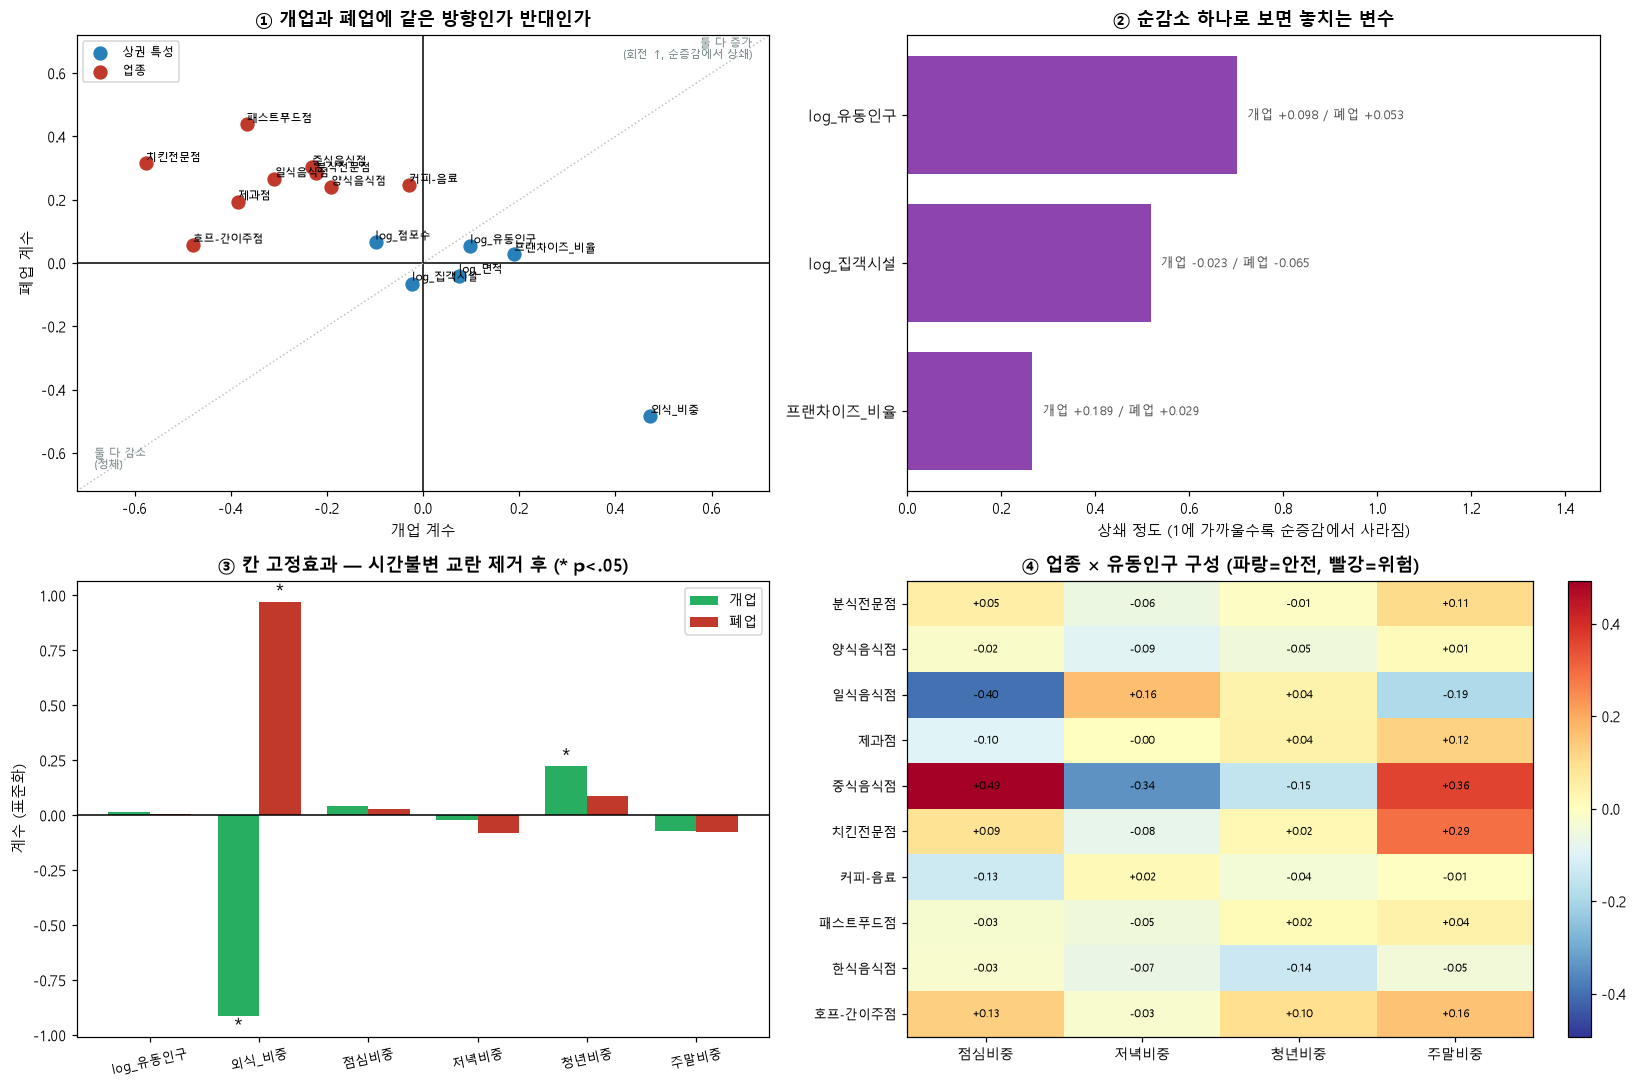

In [12]:
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

# ① 개업 vs 폐업 계수 산점도
s = cmp2.loc[[i for i in cmp2.index if not i.startswith("svc_")]]
sv = cmp2.loc[[i for i in cmp2.index if i.startswith("svc_")]]
ax[0,0].axhline(0, c="k", lw=1); ax[0,0].axvline(0, c="k", lw=1)
lim = max(cmp2[["개업_계수", "폐업_계수"]].abs().max()) * 1.25
ax[0,0].plot([-lim, lim], [-lim, lim], ls=":", c="#bdc3c7", lw=1)
ax[0,0].scatter(s["개업_계수"], s["폐업_계수"], s=70, c="#2980b9", label="상권 특성", zorder=3)
ax[0,0].scatter(sv["개업_계수"], sv["폐업_계수"], s=70, c="#c0392b", label="업종", zorder=3)
for i, r in cmp2.iterrows():
    ax[0,0].annotate(i.replace("svc_", ""), (r["개업_계수"], r["폐업_계수"]),
                     fontsize=7.5, ha="left", va="bottom")
ax[0,0].set_xlim(-lim, lim); ax[0,0].set_ylim(-lim, lim)
ax[0,0].set_xlabel("개업 계수"); ax[0,0].set_ylabel("폐업 계수")
ax[0,0].set_title("① 개업과 폐업에 같은 방향인가 반대인가", weight="bold")
ax[0,0].legend(fontsize=8)
ax[0,0].text(lim*.95, lim*.9, "둘 다 증가\n(회전 ↑, 순증감에서 상쇄)",
             fontsize=7.5, ha="right", color="#7f8c8d")
ax[0,0].text(-lim*.95, -lim*.9, "둘 다 감소\n(정체)", fontsize=7.5, ha="left", color="#7f8c8d")

# ② 상쇄 정도
t2 = sig[sig["상쇄_정도"] > .01].sort_values("상쇄_정도")
ax[0,1].barh([i.replace("svc_", "") for i in t2.index], t2["상쇄_정도"], color="#8e44ad")
for k, (i, r) in enumerate(t2.iterrows()):
    ax[0,1].text(r["상쇄_정도"], k, f"  개업 {r['개업_계수']:+.3f} / 폐업 {r['폐업_계수']:+.3f}",
                 va="center", fontsize=8.5, color="#555")
ax[0,1].set_xlim(0, t2["상쇄_정도"].max() * 2.1)
ax[0,1].set_xlabel("상쇄 정도 (1에 가까울수록 순증감에서 사라짐)")
ax[0,1].set_title("② 순감소 하나로 보면 놓치는 변수", weight="bold")

# ③ 칸 고정효과
x = np.arange(len(TV_FE)); w = .38
ax[1,0].bar(x - w/2, fe["개업_계수"], w, label="개업", color="#27ae60")
ax[1,0].bar(x + w/2, fe["폐업_계수"], w, label="폐업", color="#c0392b")
for k, v in enumerate(TV_FE):
    for off_, col in [(-w/2, "개업_p"), (w/2, "폐업_p")]:
        if fe.loc[v, col] < .05:
            yv = fe.loc[v, col.replace("_p", "_계수")]
            ax[1,0].text(x[k] + off_, yv, "*", ha="center",
                         va="bottom" if yv > 0 else "top", fontsize=13)
ax[1,0].axhline(0, c="k", lw=1)
ax[1,0].set_xticks(x); ax[1,0].set_xticklabels(TV_FE, fontsize=8.5, rotation=12)
ax[1,0].set_ylabel("계수 (표준화)")
ax[1,0].set_title("③ 칸 고정효과 — 시간불변 교란 제거 후 (* p<.05)", weight="bold")
ax[1,0].legend(fontsize=9)

# ④ 업종 × 구성 히트맵
hm = grid[INTER]
im = ax[1,1].imshow(hm.values, cmap="RdYlBu_r", aspect="auto",
                    vmin=-np.abs(hm.values).max(), vmax=np.abs(hm.values).max())
ax[1,1].set_xticks(range(len(INTER))); ax[1,1].set_xticklabels(INTER, fontsize=9)
ax[1,1].set_yticks(range(len(hm))); ax[1,1].set_yticklabels(hm.index, fontsize=8.5)
for i in range(hm.shape[0]):
    for j in range(hm.shape[1]):
        ax[1,1].text(j, i, f"{hm.values[i,j]:+.2f}", ha="center", va="center", fontsize=7.5)
ax[1,1].set_title("④ 업종 × 유동인구 구성 (파랑=안전, 빨강=위험)", weight="bold")
fig.colorbar(im, ax=ax[1,1], fraction=.046)

plt.tight_layout()
plt.savefig(FIG / "step10_extended.png", dpi=130)
plt.show()

## 10-6. 저장 및 정리

In [13]:
cmp.to_csv(OUT / "q2_open_close.csv", encoding="utf-8-sig")
fe.to_csv(OUT / "q2_cell_fe.csv", encoding="utf-8-sig")
grid.to_csv(OUT / "q2_flow_interaction.csv", encoding="utf-8-sig")
gm.to_pickle(PROC / "10_extended.pkl")
print(f"[저장] 10_extended.pkl  {gm.shape}")
print("[저장] outputs/q2_open_close.csv, q2_cell_fe.csv, q2_flow_interaction.csv")
print("[저장] figures/step10_extended.png\n")

flow_open = cmp.loc["log_유동인구", "개업_계수"]
flow_close = cmp.loc["log_유동인구", "폐업_계수"]
print("=" * 62)
print("보조질문 2 — STEP 10 이 더한 것")
print("-" * 62)
print(f"① 유동인구는 개업 {flow_open:+.3f} (p={cmp.loc['log_유동인구','개업_p']:.3f}) · "
      f"폐업 {flow_close:+.3f} (p={cmp.loc['log_유동인구','폐업_p']:.3f})")
print("   → 둘 다 같은 방향. 순증감(차이)에서 상쇄되어 '무관'하게 보였던 것입니다.")
print("   → 유동인구가 많은 상권은 위험한 게 아니라 **회전이 빠른** 상권입니다.")
print(f"② 칸 고정효과를 걸면 유동인구는 개업 p={fe.loc['log_유동인구','개업_p']:.3f} · "
      f"폐업 p={fe.loc['log_유동인구','폐업_p']:.3f}")
print("   → 같은 칸 안에서 유동인구가 변해도 개업·폐업 비율은 움직이지 않습니다.")
print("   → 횡단면 연관은 상권의 시간불변 특성이 만든 것이라는 뜻입니다.")
print("③ 유동인구 구성은 업종마다 다른 방향으로 작동합니다 (10-4 표 참조)")
print("=" * 62)

[저장] 10_extended.pkl  (31875, 52)
[저장] outputs/q2_open_close.csv, q2_cell_fe.csv, q2_flow_interaction.csv
[저장] figures/step10_extended.png

보조질문 2 — STEP 10 이 더한 것
--------------------------------------------------------------
① 유동인구는 개업 +0.098 (p=0.000) · 폐업 +0.053 (p=0.010)
   → 둘 다 같은 방향. 순증감(차이)에서 상쇄되어 '무관'하게 보였던 것입니다.
   → 유동인구가 많은 상권은 위험한 게 아니라 **회전이 빠른** 상권입니다.
② 칸 고정효과를 걸면 유동인구는 개업 p=0.865 · 폐업 p=0.963
   → 같은 칸 안에서 유동인구가 변해도 개업·폐업 비율은 움직이지 않습니다.
   → 횡단면 연관은 상권의 시간불변 특성이 만든 것이라는 뜻입니다.
③ 유동인구 구성은 업종마다 다른 방향으로 작동합니다 (10-4 표 참조)


---

## 이 단계가 바꾼 것

- **"규모가 위험"** → 개업을 줄이고 폐업을 늘리는 **두 경로**로 분해됨
- **"유동인구는 무관"** → 개업·폐업을 **같이 늘려 상쇄**되는 것. 무관이 아니라 회전
- **"상권 단위라 업종 구분 불가"** → 총량은 그렇지만 **구성 × 업종 상호작용**은 식별 가능

## 남은 한계

- `외식_비중` 은 그 칸 자신의 점포도 포함합니다. 칸 고정효과 모형에서는 자기 자신을 뺀 값으로 다시 계산해볼 여지가 있습니다
- 구성비도 상권 간 분산이 85~99% 라 칸 고정효과에서는 검정력이 낮습니다
- 조건부 로지스틱의 재고-흐름 문제는 회피했을 뿐 해결한 것이 아닙니다. 근본 해결은 **점포 단위 데이터**입니다
